# Credit Risk Data Dictionary

## Objective

This notebook documents the meaning, data quality, expected risk relationship, modeling treatment, and leakage risk of the priority variables in the application dataset.

The notebook is limited to **data understanding and feature planning**. Train/test splitting, preprocessing pipelines, resampling, and model training should be completed in the next modeling notebook.

## Notebook Structure

1. Setup and data validation  
2. Target variable  
3. Income, credit, and affordability  
4. Age and employment  
5. Education, family, and occupation  
6. External credit scores  
7. Credit bureau inquiries  
8. Leakage review  
9. Feature-engineering plan  
10. Final data-dictionary output and readiness checklist


## 1. Setup and Data Validation


In [1]:
import sys

print(sys.executable)
print(sys.version)

/Users/hxxy/Desktop/找工/credit-risk-decisioning/.venv/bin/python
3.13.1 (main, Dec  3 2024, 17:59:52) [Clang 16.0.0 (clang-1600.0.26.4)]


In [2]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
train_path = RAW_DATA_DIR / "application_train.csv"

df = pd.read_csv(train_path)

In [4]:
print("Dataset shape:", df.shape)

display(df.head())

print("TARGET exists:", "TARGET" in df.columns)

Dataset shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,...,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,...,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,NaN,0.650442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single /

TARGET exists: True


In [5]:
df["TARGET"].value_counts(dropna=False).sort_index()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [6]:
priority_check = [
    "TARGET",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "OCCUPATION_TYPE",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

variable_check = pd.DataFrame({
    "Variable": priority_check,
    "Exists": [col in df.columns for col in priority_check]
})

variable_check

,Variable,Exists
0,TARGET,True
1,AMT_INCOME_TOTAL,True
2,AMT_CREDIT,True
3,AMT_ANNUITY,True
4,DAYS_BIRTH,True
5,DAYS_EMPLOYED,True
6,NAME_EDUCATION_TYPE,True
7,NAME_FAMILY_STATUS,True
8,OCCUPATION_TYPE,True
9,EXT_SOURCE_1,True


## Data Source

This notebook uses the main application-level training dataset.

Each row represents one loan application, and `TARGET` is the binary outcome used for credit risk modeling.

The detailed meaning of `TARGET` and the prediction point will be reviewed before analyzing the predictor variables.

In [7]:
priority_variables = [
    "TARGET",
    "AMT_INCOME_TOTAL",
    "NAME_INCOME_TYPE",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "OCCUPATION_TYPE",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "AMT_REQ_CREDIT_BUREAU_HOUR",
    "AMT_REQ_CREDIT_BUREAU_DAY",
    "AMT_REQ_CREDIT_BUREAU_WEEK",
    "AMT_REQ_CREDIT_BUREAU_MON",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_YEAR"
]

In [8]:
existing_variables = [
    variable
    for variable in priority_variables
    if variable in df.columns
]

missing_variables = [
    variable
    for variable in priority_variables
    if variable not in df.columns
]

print("Existing variables:", len(existing_variables))
print("Missing variables:", missing_variables)

Existing variables: 22
Missing variables: []


In [9]:
variable_summary = pd.DataFrame({
    "Variable": existing_variables,
    "Data Type": [
        str(df[variable].dtype)
        for variable in existing_variables
    ],
    "Missing Count": [
        df[variable].isna().sum()
        for variable in existing_variables
    ],
    "Missing Rate": [
        df[variable].isna().mean()
        for variable in existing_variables
    ],
    "Unique Count": [
        df[variable].nunique(dropna=True)
        for variable in existing_variables
    ]
})

variable_summary["Missing Rate"] = (
    variable_summary["Missing Rate"] * 100
).round(2)

variable_summary = variable_summary.sort_values(
    by="Missing Rate",
    ascending=False
).reset_index(drop=True)

variable_summary

,Variable,Data Type,Missing Count,Missing Rate,Unique Count
0,EXT_SOURCE_1,float64,173378,56.38,114584
1,OCCUPATION_TYPE,str,96391,31.35,18
2,EXT_SOURCE_3,float64,60965,19.83,814
3,AMT_REQ_CREDIT_BUREAU_YEAR,float64,41519,13.50,25
4,AMT_REQ_CREDIT_BUREAU_QRT,float64,41519,13.50,11
5,AMT_REQ_CREDIT_BUREAU_MON,float64,41519,13.50,24
6,AMT_REQ_CREDIT_BUREAU_WEEK,float64,41519,13.50,9
7,AMT_REQ_CREDIT_BUREAU_DAY,float64,41519,13.50,9
8,AMT_REQ_CREDIT_BUREAU_HOUR,float64,41519,13.50,5
9,EXT_SOURCE_2,float64,660,0.21,119831


In [10]:
categorical_priority_variables = [
    variable
    for variable in existing_variables
    if (
        pd.api.types.is_string_dtype(df[variable])
        or isinstance(df[variable].dtype, pd.CategoricalDtype)
    )
]

categorical_priority_variables

['NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'OCCUPATION_TYPE']

In [11]:
numeric_priority_variables = [
    variable
    for variable in existing_variables
    if pd.api.types.is_numeric_dtype(df[variable])
]

df[numeric_priority_variables].describe().T

,count,mean,std,min,25%,50%,75%,max
TARGET,307511.0,0.080729,0.272419,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,2.565000e+04,112500.000000,147150.000000,202500.000000,1.170000e+08
AMT_CREDIT,307511.0,599025.999706,402490.776996,4.500000e+04,270000.000000,513531.000000,808650.000000,4.050000e+06
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1.615500e+03,16524.000000,24903.000000,34596.000000,2.580255e+05
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,4.050000e+04,238500.000000,450000.000000,679500.000000,4.050000e+06
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-2.522900e+04,-19682.000000,-15750.000000,-12413.000000,-7.489000e+03
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-1.791200e+04,-2760.000000,-1213.000000,-289.000000,3.652430e+05
CNT_CHILDREN,307511.0,0.417052,0.722121,0.000000e+00,0.000000,0.000000,1.000000,1.900000e+01
CNT_FAM_MEMBERS,307509.0,2.152665,0.910682,1.000000e+00,2.000000,2.000000,3.000000,2.000000e+01
EXT_SOURCE_1,134133.0,0.502130,0.211062,1.456813e-02,0.334007,0.505998,0.675053,9.626928e-01


In [12]:
df["DAYS_EMPLOYED"].value_counts().head(10)

DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-199         151
-230         151
-212         150
-229         143
-384         143
-231         140
-215         138
Name: count, dtype: int64

In [13]:
df["DAYS_EMPLOYED"].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [14]:
sentinel_count = (df["DAYS_EMPLOYED"] == 365243).sum()
sentinel_rate = sentinel_count / len(df) * 100

print("Sentinel count:", sentinel_count)
print("Sentinel rate:", round(sentinel_rate, 2), "%")

Sentinel count: 55374
Sentinel rate: 18.01 %


## 2. Target Variable

This section confirms the target definition, class distribution, missingness, and implications of class imbalance.


In [15]:
target_summary = pd.DataFrame({
    "Count": df["TARGET"].value_counts().sort_index(),
    "Rate": df["TARGET"].value_counts(
        normalize=True
    ).sort_index()
})

target_summary["Rate"] = (
    target_summary["Rate"] * 100
).round(2)

target_summary

,Count,Rate
TARGET,,
0,282686,91.93
1,24825,8.07


In [16]:
print("Unique TARGET values:", sorted(df["TARGET"].unique()))
print("Missing TARGET:", df["TARGET"].isna().sum())

Unique TARGET values: [np.int64(0), np.int64(1)]
Missing TARGET: 0


## Target Variable

`TARGET` is the binary outcome variable for this credit risk project.

- `TARGET = 0` represents the majority class.
- `TARGET = 1` represents applicants who experienced the dataset-defined payment difficulty outcome.
- The positive class accounts for approximately 8.07% of the observations.
- The target has no missing values.

Because the dataset is imbalanced, accuracy alone will not be sufficient for model evaluation. Later modeling stages will also evaluate recall, precision, ROC-AUC, PR-AUC, and the business impact of false positives and false negatives.

## 3. Income, Credit, and Affordability Variables

This section reviews absolute monetary variables first, then evaluates relative affordability measures.  
High values are not removed automatically; they require distributional and business review.


In [17]:
financial_variables = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE"
]

df[financial_variables].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.0,238500.0,450000.0,679500.0,4050000.0


In [18]:
financial_checks = pd.DataFrame({
    "Variable": financial_variables,
    "Missing Count": [
        df[col].isna().sum()
        for col in financial_variables
    ],
    "Zero Count": [
        (df[col] == 0).sum()
        for col in financial_variables
    ],
    "Negative Count": [
        (df[col] < 0).sum()
        for col in financial_variables
    ],
    "Minimum": [
        df[col].min()
        for col in financial_variables
    ],
    "Maximum": [
        df[col].max()
        for col in financial_variables
    ]
})

financial_checks

,Variable,Missing Count,Zero Count,Negative Count,Minimum,Maximum
0,AMT_INCOME_TOTAL,0,0,0,25650.0,117000000.0
1,AMT_CREDIT,0,0,0,45000.0,4050000.0
2,AMT_ANNUITY,12,0,0,1615.5,258025.5
3,AMT_GOODS_PRICE,278,0,0,40500.0,4050000.0


In [19]:
financial_target_summary = (
    df.groupby("TARGET")[financial_variables]
    .agg(["count", "mean", "median"])
    .T
)

financial_target_summary

TARGET                               0              1
AMT_INCOME_TOTAL count   282686.000000   24825.000000
                 mean    169077.722266  165611.760906
                 median  148500.000000  135000.000000
AMT_CREDIT       count   282686.000000   24825.000000
                 mean    602648.282002  557778.527674
                 median  517788.000000  497520.000000
AMT_ANNUITY      count   282674.000000   24825.000000
                 mean     27163.623349   26481.744290
                 median   24876.000000   25263.000000
AMT_GOODS_PRICE  count   282429.000000   24804.000000
                 mean    542736.795003  488972.412554
                 median  450000.000000  450000.000000

In [20]:
financial_quantiles = df[financial_variables].quantile(
    [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

financial_quantiles

,0.01,0.05,0.25,0.50,0.75,0.95,0.99
AMT_INCOME_TOTAL,45000.00,67500.0,112500.0,147150.0,202500.0,337500.0,472500.0
AMT_CREDIT,76410.00,135000.0,270000.0,513531.0,808650.0,1350000.0,1854000.0
AMT_ANNUITY,6182.91,9000.0,16524.0,24903.0,34596.0,53325.0,70006.5
AMT_GOODS_PRICE,67500.00,135000.0,238500.0,450000.0,679500.0,1305000.0,1800000.0


### Quantile Analysis

All four financial variables show evidence of right-skewed distributions. Their upper percentiles increase much more rapidly than their lower percentiles, indicating long upper tails.

`AMT_GOODS_PRICE` and `AMT_CREDIT` show particularly large differences between the median and the 99th percentile. `AMT_INCOME_TOTAL` also contains a substantial high-income tail, while `AMT_ANNUITY` appears moderately right-skewed.

These high values should not be removed automatically because they may represent valid high-income applicants, large loans, or expensive financed goods. The variables will require further review using maximum values, skewness statistics, visual distributions, and business context. Log transformations or outlier capping may be considered during feature engineering.

In [21]:
ratio_preview = df[
    [
        "TARGET",
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "AMT_GOODS_PRICE"
    ]
].copy()

ratio_preview["CREDIT_INCOME_RATIO"] = (
    ratio_preview["AMT_CREDIT"]
    / ratio_preview["AMT_INCOME_TOTAL"]
)

ratio_preview["ANNUITY_INCOME_RATIO"] = (
    ratio_preview["AMT_ANNUITY"]
    / ratio_preview["AMT_INCOME_TOTAL"]
)

ratio_preview["CREDIT_GOODS_RATIO"] = (
    ratio_preview["AMT_CREDIT"]
    / ratio_preview["AMT_GOODS_PRICE"]
)

In [22]:
ratio_variables = [
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_GOODS_RATIO"
]

ratio_preview.groupby("TARGET")[ratio_variables].agg(
    ["count", "mean", "median"]
).T

TARGET                                   0             1
CREDIT_INCOME_RATIO  count   282686.000000  24825.000000
                     mean         3.963729      3.887438
                     median       3.266653      3.253143
ANNUITY_INCOME_RATIO count   282674.000000  24825.000000
                     mean         0.180530      0.185482
                     median       0.162280      0.169294
CREDIT_GOODS_RATIO   count   282429.000000  24804.000000
                     mean         1.120443      1.152056
                     median       1.118800      1.145200

## Income, Credit, and Affordability Variables

The financial variables in this section describe applicant income, loan size, periodic payment burden, and the price of the financed goods.

Absolute monetary values should not be interpreted in isolation. A larger loan or annuity may be affordable for a high-income applicant but burdensome for a lower-income applicant. Therefore, both the original variables and relative affordability measures will be considered.

Planned engineered features include:

- credit-to-income ratio
- annuity-to-income ratio
- credit-to-goods-price ratio

The observed relationships with `TARGET` are treated as exploratory associations rather than causal conclusions.

| Variable | Business Meaning | Missing-Value Interpretation | Expected Relationship with TARGET | Modeling Decision | Leakage Risk |
|---|---|---|---|---|---|
| AMT_INCOME_TOTAL | Applicant's reported total income | Missing values may indicate unavailable or unreported income; confirm actual missingness | Higher income may be associated with lower repayment risk, but the relationship may be nonlinear and affected by debt burden | Keep; inspect outliers; consider log transformation; use in affordability ratios | Low if available at application time |
| AMT_CREDIT | Loan credit amount | Missingness would require investigation because loan amount is expected to be available | Larger credit may increase burden, but higher-quality applicants may also receive larger loans | Keep; inspect outliers; create credit-to-income ratio | Low if known at decision time |
| AMT_ANNUITY | Periodic loan payment amount | Small missingness may reflect incomplete loan terms or processing issues | Higher annuity relative to income may be associated with higher repayment risk | Keep; impute carefully if needed; create annuity-to-income ratio | Low if calculated before the credit decision |
| AMT_GOODS_PRICE | Price of the financed goods | Missingness may reflect unavailable or non-applicable goods-price information | Relationship is indirect and should be interpreted with credit amount | Keep; inspect missingness; create credit-to-goods-price ratio | Low if available at application time |

In [23]:
ratio_checks = pd.DataFrame({
    "Variable": [
        "CREDIT_INCOME_RATIO",
        "ANNUITY_INCOME_RATIO",
        "CREDIT_GOODS_RATIO"
    ],
    "Missing Count": [
        ratio_preview[col].isna().sum()
        for col in [
            "CREDIT_INCOME_RATIO",
            "ANNUITY_INCOME_RATIO",
            "CREDIT_GOODS_RATIO"
        ]
    ],
    "Infinite Count": [
        np.isinf(ratio_preview[col]).sum()
        for col in [
            "CREDIT_INCOME_RATIO",
            "ANNUITY_INCOME_RATIO",
            "CREDIT_GOODS_RATIO"
        ]
    ],
    "Median": [
        ratio_preview[col].median()
        for col in [
            "CREDIT_INCOME_RATIO",
            "ANNUITY_INCOME_RATIO",
            "CREDIT_GOODS_RATIO"
        ]
    ],
    "99th Percentile": [
        ratio_preview[col].quantile(0.99)
        for col in [
            "CREDIT_INCOME_RATIO",
            "ANNUITY_INCOME_RATIO",
            "CREDIT_GOODS_RATIO"
        ]
    ],
    "Maximum": [
        ratio_preview[col].max()
        for col in [
            "CREDIT_INCOME_RATIO",
            "ANNUITY_INCOME_RATIO",
            "CREDIT_GOODS_RATIO"
        ]
    ]
})

ratio_checks

,Variable,Missing Count,Infinite Count,Median,99th Percentile,Maximum
0,CREDIT_INCOME_RATIO,0,0,3.265067,13.027280,84.736842
1,ANNUITY_INCOME_RATIO,12,0,0.162833,0.483458,1.875965
2,CREDIT_GOODS_RATIO,278,0,1.118800,1.475200,6.000000


In [24]:
ratio_target_summary = (
    ratio_preview
    .groupby("TARGET")[
        [
            "CREDIT_INCOME_RATIO",
            "ANNUITY_INCOME_RATIO",
            "CREDIT_GOODS_RATIO"
        ]
    ]
    .agg(["count", "mean", "median"])
    .T
)

ratio_target_summary

TARGET                                   0             1
CREDIT_INCOME_RATIO  count   282686.000000  24825.000000
                     mean         3.963729      3.887438
                     median       3.266653      3.253143
ANNUITY_INCOME_RATIO count   282674.000000  24825.000000
                     mean         0.180530      0.185482
                     median       0.162280      0.169294
CREDIT_GOODS_RATIO   count   282429.000000  24804.000000
                     mean         1.120443      1.152056
                     median       1.118800      1.145200

In [25]:
credit_above_goods = ratio_preview[
    ratio_preview["CREDIT_GOODS_RATIO"] > 1
]

print("Count:", len(credit_above_goods))
print(
    "Rate:",
    round(len(credit_above_goods) / len(ratio_preview) * 100, 2),
    "%"
)

credit_above_goods[
    [
        "AMT_CREDIT",
        "AMT_GOODS_PRICE",
        "CREDIT_GOODS_RATIO",
        "TARGET"
    ]
].head(10)

Count: 198763
Rate: 64.64 %


,AMT_CREDIT,AMT_GOODS_PRICE,CREDIT_GOODS_RATIO,TARGET
0,406597.5,351000.0,1.158397,1
1,1293502.5,1129500.0,1.145199,0
3,312682.5,297000.0,1.052803,0
5,490495.5,454500.0,1.079198,0
6,1560726.0,1395000.0,1.118800,0
8,1019610.0,913500.0,1.116158,0
11,148365.0,135000.0,1.099000,0
12,80865.0,67500.0,1.198000,0
13,918468.0,697500.0,1.316800,0
14,773680.5,679500.0,1.138603,0


## 4. Age and Employment Variables

Day-based offsets are converted into interpretable year-based features.  
The `DAYS_EMPLOYED = 365243` sentinel is treated as unavailable information rather than a valid duration.


In [26]:
time_variables = [
    "DAYS_BIRTH",
    "DAYS_EMPLOYED"
]

df[time_variables].describe().T

,count,mean,std,min,25%,50%,75%,max
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-25229.0,-19682.0,-15750.0,-12413.0,-7489.0
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.0,-2760.0,-1213.0,-289.0,365243.0


In [27]:
print("DAYS_BIRTH unique values:", df["DAYS_BIRTH"].nunique())
print("DAYS_EMPLOYED unique values:", df["DAYS_EMPLOYED"].nunique())

print(
    "DAYS_EMPLOYED sentinel count:",
    (df["DAYS_EMPLOYED"] == 365243).sum()
)

print(
    "DAYS_EMPLOYED sentinel rate:",
    round(
        (df["DAYS_EMPLOYED"] == 365243).mean() * 100,
        2
    ),
    "%"
)

DAYS_BIRTH unique values: 17460
DAYS_EMPLOYED unique values: 12574
DAYS_EMPLOYED sentinel count: 55374
DAYS_EMPLOYED sentinel rate: 18.01 %


In [28]:
age_preview = df[
    [
        "TARGET",
        "DAYS_BIRTH",
        "DAYS_EMPLOYED"
    ]
].copy()

age_preview["AGE_YEARS"] = (
    -age_preview["DAYS_BIRTH"] / 365.25
)

In [29]:
age_preview["AGE_YEARS"].describe()

count    307511.000000
mean         43.906900
std          11.947950
min          20.503765
25%          33.984942
50%          43.121150
75%          53.886379
max          69.073238
Name: AGE_YEARS, dtype: float64

In [30]:
age_preview["AGE_YEARS"].quantile(
    [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

0.01    22.622861
0.05    25.754962
0.25    33.984942
0.50    43.121150
0.75    53.886379
0.95    63.529090
0.99    66.855578
Name: AGE_YEARS, dtype: float64

In [31]:
print(
    "Age below 18:",
    (age_preview["AGE_YEARS"] < 18).sum()
)

print(
    "Age above 100:",
    (age_preview["AGE_YEARS"] > 100).sum()
)

Age below 18: 0
Age above 100: 0


In [32]:
age_preview["EMPLOYMENT_MISSING_FLAG"] = (
    age_preview["DAYS_EMPLOYED"] == 365243
).astype(int)

In [33]:
age_preview["DAYS_EMPLOYED_CLEAN"] = (
    age_preview["DAYS_EMPLOYED"]
    .replace(365243, np.nan)
)

In [34]:
age_preview["EMPLOYMENT_YEARS"] = (
    -age_preview["DAYS_EMPLOYED_CLEAN"] / 365.25
)

In [35]:
age_preview["EMPLOYMENT_YEARS"].describe()

count    252137.000000
mean          6.527500
std           6.402081
min          -0.000000
25%           2.099932
50%           4.511978
75%           8.692676
max          49.040383
Name: EMPLOYMENT_YEARS, dtype: float64

In [36]:
print(
    "Employment years below 0:",
    (age_preview["EMPLOYMENT_YEARS"] < 0).sum()
)

print(
    "Employment years above 60:",
    (age_preview["EMPLOYMENT_YEARS"] > 60).sum()
)

Employment years below 0: 0
Employment years above 60: 0


In [37]:
age_preview["EMPLOYMENT_AGE_GAP"] = (
    age_preview["AGE_YEARS"]
    - age_preview["EMPLOYMENT_YEARS"]
)

print(
    "Employment years greater than age:",
    (
        age_preview["EMPLOYMENT_YEARS"]
        > age_preview["AGE_YEARS"]
    ).sum()
)

Employment years greater than age: 0


In [38]:
age_target_summary = (
    age_preview
    .groupby("TARGET")[
        [
            "AGE_YEARS",
            "EMPLOYMENT_YEARS",
            "EMPLOYMENT_MISSING_FLAG"
        ]
    ]
    .agg(["count", "mean", "median"])
    .T
)

age_target_summary

TARGET                                      0             1
AGE_YEARS               count   282686.000000  24825.000000
                        mean        44.183919     40.752438
                        median      43.468857     39.101985
EMPLOYMENT_YEARS        count   230302.000000  21835.000000
                        mean         6.675264      4.968977
                        median       4.629706      3.367556
EMPLOYMENT_MISSING_FLAG count   282686.000000  24825.000000
                        mean         0.185308      0.120443
                        median       0.000000      0.000000

In [39]:
age_preview.groupby("TARGET")[
    "EMPLOYMENT_MISSING_FLAG"
].mean()

TARGET
0    0.185308
1    0.120443
Name: EMPLOYMENT_MISSING_FLAG, dtype: float64

## Age and Employment Variables

`DAYS_BIRTH` and `DAYS_EMPLOYED` are stored as day-based offsets relative to the application date.

For interpretability:

- `DAYS_BIRTH` will be converted into `AGE_YEARS`.
- Valid `DAYS_EMPLOYED` values will be converted into `EMPLOYMENT_YEARS`.
- The special value `365243` in `DAYS_EMPLOYED` will be treated as unavailable employment information rather than a valid duration.
- A separate missing-value indicator will be retained because the special code may carry predictive information.

The relationships between age, employment tenure, and `TARGET` will be treated as potentially nonlinear.

| Variable | Business Meaning | Missing-Value Interpretation | Expected Relationship with TARGET | Modeling Decision | Leakage Risk |
|---|---|---|---|---|---|
| DAYS_BIRTH | Applicant age represented as days before application | No explicit missing values expected; invalid ranges still require review | Younger applicants may have shorter credit histories, but the relationship may be nonlinear | Convert to AGE_YEARS; validate range; drop original day-based field after transformation | Low if known at application time |
| DAYS_EMPLOYED | Employment duration represented as days before application | 365243 is a special code for unavailable or non-applicable employment information | Longer employment tenure may be associated with lower risk; missing employment information may also be informative | Replace 365243 with missing; create EMPLOYMENT_MISSING_FLAG; convert valid values to EMPLOYMENT_YEARS | Low if known at application time |

## 5. Education, Family, and Occupation Variables

Categorical target rates must always be interpreted together with sample count and population share.  
Missing occupation is retained as an explicit category rather than automatically replaced by the mode.


In [40]:
categorical_variables = [
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "OCCUPATION_TYPE"
]

for col in categorical_variables:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- NAME_EDUCATION_TYPE ---
NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64

--- NAME_FAMILY_STATUS ---
NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2
Name: count, dtype: int64

--- OCCUPATION_TYPE ---
OCCUPATION_TYPE
NaN                      96391
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Cooking staff             5946
Cleaning staff            4653
Private service staff     2652
Low-skill Laborers    

In [41]:
def categorical_target_summary(data, column, target="TARGET"):
    summary = (
        data.groupby(column, dropna=False)[target]
        .agg(["count", "mean"])
        .rename(columns={
            "count": "Sample Count",
            "mean": "Target Rate"
        })
        .sort_values(
            by="Target Rate",
            ascending=False
        )
    )

    summary["Target Rate"] = (
        summary["Target Rate"] * 100
    ).round(2)

    summary["Population Share"] = (
        summary["Sample Count"] / len(data) * 100
    ).round(2)

    return summary

In [42]:
education_summary = categorical_target_summary(
    df,
    "NAME_EDUCATION_TYPE"
)

education_summary

,Sample Count,Target Rate,Population Share
NAME_EDUCATION_TYPE,,,
Lower secondary,3816,10.93,1.24
Secondary / secondary special,218391,8.94,71.02
Incomplete higher,10277,8.48,3.34
Higher education,74863,5.36,24.34
Academic degree,164,1.83,0.05


In [43]:
family_status_summary = categorical_target_summary(
    df,
    "NAME_FAMILY_STATUS"
)

family_status_summary

,Sample Count,Target Rate,Population Share
NAME_FAMILY_STATUS,,,
Civil marriage,29775,9.94,9.68
Single / not married,45444,9.81,14.78
Separated,19770,8.19,6.43
Married,196432,7.56,63.88
Widow,16088,5.82,5.23
Unknown,2,0.00,0.00


In [44]:
occupation_summary = categorical_target_summary(
    df,
    "OCCUPATION_TYPE"
)

occupation_summary

,Sample Count,Target Rate,Population Share
OCCUPATION_TYPE,,,
Low-skill Laborers,2093,17.15,0.68
Drivers,18603,11.33,6.05
Waiters/barmen staff,1348,11.28,0.44
Security staff,6721,10.74,2.19
Laborers,55186,10.58,17.95
Cooking staff,5946,10.44,1.93
Sales staff,32102,9.63,10.44
Cleaning staff,4653,9.61,1.51
Realty agents,751,7.86,0.24


In [45]:
occupation_preview = df[
    [
        "TARGET",
        "OCCUPATION_TYPE"
    ]
].copy()

occupation_preview["OCCUPATION_TYPE_CLEAN"] = (
    occupation_preview["OCCUPATION_TYPE"]
    .fillna("Unknown")
)

In [46]:
categorical_target_summary(
    occupation_preview,
    "OCCUPATION_TYPE_CLEAN"
)

,Sample Count,Target Rate,Population Share
OCCUPATION_TYPE_CLEAN,,,
Low-skill Laborers,2093,17.15,0.68
Drivers,18603,11.33,6.05
Waiters/barmen staff,1348,11.28,0.44
Security staff,6721,10.74,2.19
Laborers,55186,10.58,17.95
Cooking staff,5946,10.44,1.93
Sales staff,32102,9.63,10.44
Cleaning staff,4653,9.61,1.51
Realty agents,751,7.86,0.24


In [47]:
family_variables = [
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS"
]

df[family_variables].describe().T

,count,mean,std,min,25%,50%,75%,max
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
CNT_FAM_MEMBERS,307509.0,2.152665,0.910682,1.0,2.0,2.0,3.0,20.0


In [48]:
family_checks = pd.DataFrame({
    "Variable": family_variables,
    "Missing Count": [
        df[col].isna().sum()
        for col in family_variables
    ],
    "Minimum": [
        df[col].min()
        for col in family_variables
    ],
    "Median": [
        df[col].median()
        for col in family_variables
    ],
    "Maximum": [
        df[col].max()
        for col in family_variables
    ]
})

family_checks

,Variable,Missing Count,Minimum,Median,Maximum
0,CNT_CHILDREN,0,0.0,0.0,19.0
1,CNT_FAM_MEMBERS,2,1.0,2.0,20.0


In [49]:
print(
    "Children greater than family members:",
    (
        df["CNT_CHILDREN"]
        > df["CNT_FAM_MEMBERS"]
    ).sum()
)

Children greater than family members: 0


In [50]:
family_preview = df[
    [
        "TARGET",
        "CNT_CHILDREN",
        "CNT_FAM_MEMBERS"
    ]
].copy()

safe_family_size = (
    family_preview["CNT_FAM_MEMBERS"]
    .replace(0, np.nan)
)

family_preview["CHILDREN_FAMILY_RATIO"] = (
    family_preview["CNT_CHILDREN"]
    / safe_family_size
)

## Education, Family, and Occupation Variables

The variables in this section describe applicant education, family structure, and occupation.

Categorical target rates will always be interpreted together with sample size because categories with very small populations may show unstable default-rate estimates.

Missing occupation values will be retained as a separate `"Unknown"` category rather than replaced with the most common occupation. This preserves the information that occupational data was unavailable.

These variables may be associated with repayment risk, but they should not be interpreted as direct causal drivers. Their use also requires careful consideration of fairness, compliance, and business context.

| Variable | Business Meaning | Missing-Value Interpretation | Expected Relationship with TARGET | Modeling Decision | Leakage Risk |
|---|---|---|---|---|---|
| NAME_EDUCATION_TYPE | Applicant's highest reported education level | Missingness may indicate unavailable or unreported education information | Education may be associated with risk through income and employment stability, but the relationship may not be monotonic | Keep; review rare categories; use one-hot encoding | Low if collected at application time |
| NAME_FAMILY_STATUS | Applicant's reported marital or family status | Missingness may represent unreported or unknown family status | May be associated with household resources and financial obligations | Keep for evaluation; one-hot encode; review fairness implications | Low if collected at application time |
| OCCUPATION_TYPE | Applicant's reported occupation category | Missingness may represent unavailable, unreported, unemployed, retired, or non-applicable status | Occupation may be associated with income stability, while missingness may also be informative | Fill missing values with Unknown; combine rare categories if justified; one-hot encode | Low if available at application time |
| CNT_CHILDREN | Number of children in the household | Missing values would require review | More dependents may increase financial burden, but the effect depends on income and family size | Keep; inspect extreme values; evaluate with family size and income | Low |
| CNT_FAM_MEMBERS | Number of family members | Missingness may indicate incomplete household information | Larger households may increase expenses, but may also contain multiple earners | Keep; review missing and zero values; consider family-related ratios | Low |

## 6. External Credit Score Variables

This section evaluates score coverage, directionality, missingness patterns, combined-score candidates, and correlation.


In [51]:
external_score_variables = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

external_score_summary = pd.DataFrame({
    "Variable": external_score_variables,
    "Missing Count": [
        df[col].isna().sum()
        for col in external_score_variables
    ],
    "Missing Rate": [
        df[col].isna().mean() * 100
        for col in external_score_variables
    ],
    "Minimum": [
        df[col].min()
        for col in external_score_variables
    ],
    "Median": [
        df[col].median()
        for col in external_score_variables
    ],
    "Maximum": [
        df[col].max()
        for col in external_score_variables
    ],
    "Unique Count": [
        df[col].nunique()
        for col in external_score_variables
    ]
})

external_score_summary["Missing Rate"] = (
    external_score_summary["Missing Rate"]
    .round(2)
)

external_score_summary

,Variable,Missing Count,Missing Rate,Minimum,Median,Maximum,Unique Count
0,EXT_SOURCE_1,173378,56.38,1.456813e-02,0.505998,0.962693,114584
1,EXT_SOURCE_2,660,0.21,8.173617e-08,0.565961,0.855000,119831
2,EXT_SOURCE_3,60965,19.83,5.272652e-04,0.535276,0.896010,814


In [52]:
df[external_score_variables].quantile(
    [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

,0.01,0.05,0.25,0.50,0.75,0.95,0.99
EXT_SOURCE_1,0.084257,0.158021,0.334007,0.505998,0.675053,0.832260,0.889411
EXT_SOURCE_2,0.029477,0.133299,0.392457,0.565961,0.663617,0.747734,0.782793
EXT_SOURCE_3,0.064672,0.154744,0.370650,0.535276,0.669057,0.786267,0.832785


In [53]:
external_target_summary = (
    df.groupby("TARGET")[external_score_variables]
    .agg(["count", "mean", "median"])
    .T
)

external_target_summary

TARGET                           0             1
EXT_SOURCE_1 count   124079.000000  10054.000000
             mean         0.511461      0.386968
             median       0.517452      0.361675
EXT_SOURCE_2 count   282078.000000  24773.000000
             mean         0.523479      0.410935
             median       0.573905      0.440381
EXT_SOURCE_3 count   227398.000000  19148.000000
             mean         0.520969      0.390717
             median       0.546023      0.379100

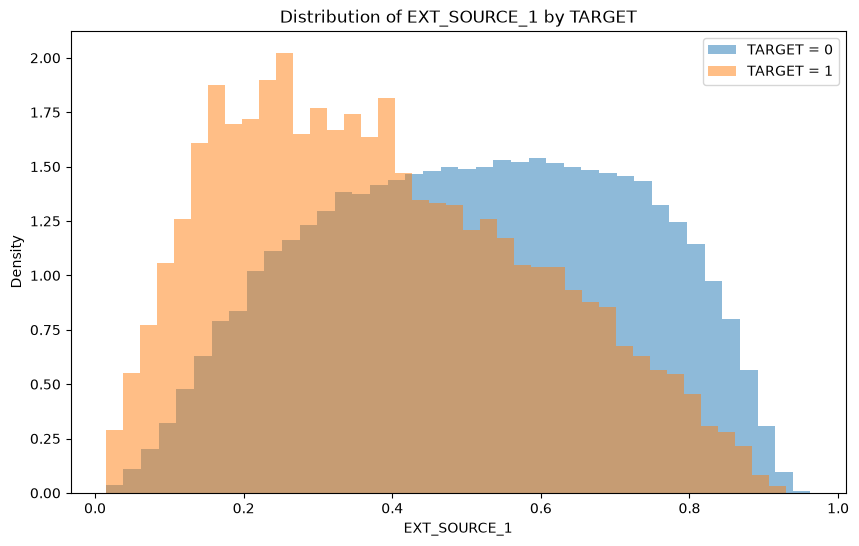

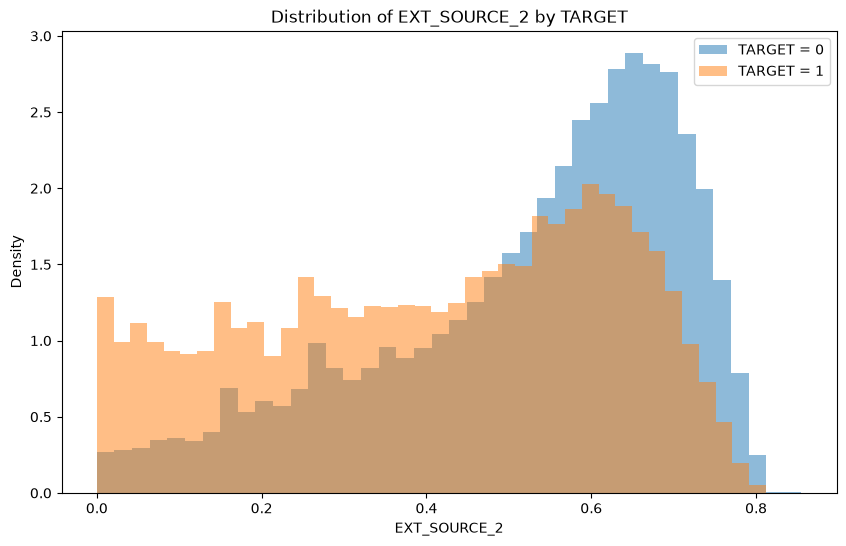

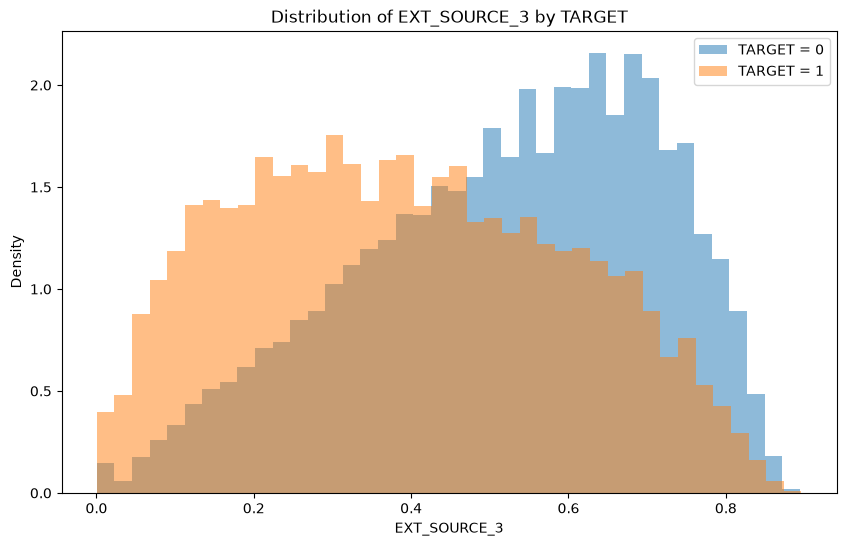

In [54]:
import matplotlib.pyplot as plt

for col in external_score_variables:
    plt.figure(figsize=(10, 6))

    plt.hist(
        df.loc[df["TARGET"] == 0, col].dropna(),
        bins=40,
        alpha=0.5,
        density=True,
        label="TARGET = 0"
    )

    plt.hist(
        df.loc[df["TARGET"] == 1, col].dropna(),
        bins=40,
        alpha=0.5,
        density=True,
        label="TARGET = 1"
    )

    plt.title(f"Distribution of {col} by TARGET")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.show()

In [55]:
external_preview = df[
    [
        "TARGET",
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3"
    ]
].copy()

for col in external_score_variables:
    external_preview[f"{col}_MISSING_FLAG"] = (
        external_preview[col].isna().astype(int)
    )

In [56]:
for col in external_score_variables:
    flag_col = f"{col}_MISSING_FLAG"

    result = (
        external_preview
        .groupby(flag_col)["TARGET"]
        .agg(["count", "mean"])
    )

    result["mean"] = (
        result["mean"] * 100
    ).round(2)

    print(f"\n--- {col} missing flag ---")
    display(result)


--- EXT_SOURCE_1 missing flag ---


,count,mean
EXT_SOURCE_1_MISSING_FLAG,,
0,134133,7.50
1,173378,8.52



--- EXT_SOURCE_2 missing flag ---


,count,mean
EXT_SOURCE_2_MISSING_FLAG,,
0,306851,8.07
1,660,7.88



--- EXT_SOURCE_3 missing flag ---


,count,mean
EXT_SOURCE_3_MISSING_FLAG,,
0,246546,7.77
1,60965,9.31


In [57]:
external_preview["EXT_SOURCE_MEAN"] = (
    external_preview[
        [
            "EXT_SOURCE_1",
            "EXT_SOURCE_2",
            "EXT_SOURCE_3"
        ]
    ]
    .mean(axis=1, skipna=True)
)

In [58]:
external_preview["EXT_SOURCE_AVAILABLE_COUNT"] = (
    external_preview[
        [
            "EXT_SOURCE_1",
            "EXT_SOURCE_2",
            "EXT_SOURCE_3"
        ]
    ]
    .notna()
    .sum(axis=1)
)

In [59]:
external_preview[
    [
        "EXT_SOURCE_MEAN",
        "EXT_SOURCE_AVAILABLE_COUNT"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
EXT_SOURCE_MEAN,307339.0,0.509251,0.149802,0.000006,0.413648,0.524502,0.622819,0.878903
EXT_SOURCE_AVAILABLE_COUNT,307511.0,2.235790,0.649986,0.000000,2.000000,2.000000,3.000000,3.000000


In [60]:
external_preview.groupby("TARGET")[
    [
        "EXT_SOURCE_MEAN",
        "EXT_SOURCE_AVAILABLE_COUNT"
    ]
].agg(["count", "mean", "median"]).T

TARGET                                         0             1
EXT_SOURCE_MEAN            count   282528.000000  24811.000000
                           mean         0.519109      0.397003
                           median       0.533791      0.399057
EXT_SOURCE_AVAILABLE_COUNT count   282686.000000  24825.000000
                           mean         2.241197      2.174220
                           median       2.000000      2.000000

In [61]:
external_preview[
    [
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3"
    ]
].corr()

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
EXT_SOURCE_1,1.000000,0.213982,0.186846
EXT_SOURCE_2,0.213982,1.000000,0.109167
EXT_SOURCE_3,0.186846,0.109167,1.000000


## External Credit Score Variables

`EXT_SOURCE_1`, `EXT_SOURCE_2`, and `EXT_SOURCE_3` are externally derived score variables associated with applicant credit quality or repayment risk.

The three variables have substantially different coverage rates, particularly `EXT_SOURCE_1`, which has a high level of missingness. Missing values will not automatically be interpreted as average credit quality.

The analysis will evaluate:

- score direction relative to `TARGET`
- missingness patterns
- individual score performance
- combined score summaries
- correlations across external sources

Missing indicators will be retained because score availability may itself contain predictive information.

| Variable | Business Meaning | Missing-Value Interpretation | Expected Relationship with TARGET | Modeling Decision | Leakage Risk |
|---|---|---|---|---|---|
| EXT_SOURCE_1 | External standardized score related to applicant credit profile or risk | Missingness may indicate unavailable history, failed matching, or limited source coverage | Higher scores may be associated with lower repayment risk; confirm direction empirically | Keep; median imputation if required; add missing flag; evaluate nonlinear relationship | Low if generated using information available at application time |
| EXT_SOURCE_2 | External standardized score related to applicant credit profile or risk | Very low missingness; missing records may reflect source or matching issues | Higher scores may be associated with lower repayment risk | Keep; handle small missingness; evaluate distribution and interactions | Low if available at application time |
| EXT_SOURCE_3 | External standardized score related to applicant credit profile or risk | Missingness may reflect unavailable or incomplete external data | Higher scores may be associated with lower repayment risk | Keep; median imputation if required; add missing flag | Low if generated before the lending decision |

## 7. Credit Bureau Inquiry Variables

Zero means no recorded inquiry when data is available; missing means the inquiry information is unavailable.  
Overlapping time windows are not summed and interpreted as unique inquiries without documentation.


In [62]:
bureau_inquiry_variables = [
    "AMT_REQ_CREDIT_BUREAU_HOUR",
    "AMT_REQ_CREDIT_BUREAU_DAY",
    "AMT_REQ_CREDIT_BUREAU_WEEK",
    "AMT_REQ_CREDIT_BUREAU_MON",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_YEAR"
]

In [63]:
bureau_inquiry_summary = pd.DataFrame({
    "Variable": bureau_inquiry_variables,

    "Missing Count": [
        df[col].isna().sum()
        for col in bureau_inquiry_variables
    ],

    "Missing Rate": [
        df[col].isna().mean() * 100
        for col in bureau_inquiry_variables
    ],

    "Zero Count": [
        (df[col] == 0).sum()
        for col in bureau_inquiry_variables
    ],

    "Zero Rate Among Non-Missing": [
        (df[col] == 0).sum() / df[col].notna().sum() * 100
        for col in bureau_inquiry_variables
    ],

    "Minimum": [
        df[col].min()
        for col in bureau_inquiry_variables
    ],

    "Median": [
        df[col].median()
        for col in bureau_inquiry_variables
    ],

    "Maximum": [
        df[col].max()
        for col in bureau_inquiry_variables
    ]
})

bureau_inquiry_summary[
    ["Missing Rate", "Zero Rate Among Non-Missing"]
] = bureau_inquiry_summary[
    ["Missing Rate", "Zero Rate Among Non-Missing"]
].round(2)

bureau_inquiry_summary

,Variable,Missing Count,Missing Rate,Zero Count,Zero Rate Among Non-Missing,Minimum,Median,Maximum
0,AMT_REQ_CREDIT_BUREAU_HOUR,41519,13.5,264366,99.39,0.0,0.0,4.0
1,AMT_REQ_CREDIT_BUREAU_DAY,41519,13.5,264503,99.44,0.0,0.0,9.0
2,AMT_REQ_CREDIT_BUREAU_WEEK,41519,13.5,257456,96.79,0.0,0.0,8.0
3,AMT_REQ_CREDIT_BUREAU_MON,41519,13.5,222233,83.55,0.0,0.0,27.0
4,AMT_REQ_CREDIT_BUREAU_QRT,41519,13.5,215417,80.99,0.0,0.0,261.0
5,AMT_REQ_CREDIT_BUREAU_YEAR,41519,13.5,71801,26.99,0.0,1.0,25.0


In [64]:
df[bureau_inquiry_variables].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99]
).T

,0.50,0.75,0.90,0.95,0.99
AMT_REQ_CREDIT_BUREAU_HOUR,0.0,0.0,0.0,0.0,0.0
AMT_REQ_CREDIT_BUREAU_DAY,0.0,0.0,0.0,0.0,0.0
AMT_REQ_CREDIT_BUREAU_WEEK,0.0,0.0,0.0,0.0,1.0
AMT_REQ_CREDIT_BUREAU_MON,0.0,0.0,1.0,1.0,4.0
AMT_REQ_CREDIT_BUREAU_QRT,0.0,0.0,1.0,2.0,2.0
AMT_REQ_CREDIT_BUREAU_YEAR,1.0,3.0,4.0,6.0,8.0


In [65]:
df[bureau_inquiry_variables].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_REQ_CREDIT_BUREAU_HOUR,265992.0,0.006402,0.083849,0.0,0.0,0.0,0.0,4.0
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0
AMT_REQ_CREDIT_BUREAU_YEAR,265992.0,1.899974,1.869295,0.0,0.0,1.0,3.0,25.0


In [66]:
for col in bureau_inquiry_variables:
    negative_count = (df[col] < 0).sum()

    print(
        col,
        "negative count:",
        negative_count
    )

AMT_REQ_CREDIT_BUREAU_HOUR negative count: 0
AMT_REQ_CREDIT_BUREAU_DAY negative count: 0
AMT_REQ_CREDIT_BUREAU_WEEK negative count: 0
AMT_REQ_CREDIT_BUREAU_MON negative count: 0
AMT_REQ_CREDIT_BUREAU_QRT negative count: 0
AMT_REQ_CREDIT_BUREAU_YEAR negative count: 0


In [67]:
bureau_target_summary = (
    df.groupby("TARGET")[bureau_inquiry_variables]
    .agg(["count", "mean", "median"])
    .T
)

bureau_target_summary

TARGET                                         0             1
AMT_REQ_CREDIT_BUREAU_HOUR count   245459.000000  20533.000000
                           mean         0.006380      0.006672
                           median       0.000000      0.000000
AMT_REQ_CREDIT_BUREAU_DAY  count   245459.000000  20533.000000
                           mean         0.006914      0.008036
                           median       0.000000      0.000000
AMT_REQ_CREDIT_BUREAU_WEEK count   245459.000000  20533.000000
                           mean         0.034315      0.034919
                           median       0.000000      0.000000
AMT_REQ_CREDIT_BUREAU_MON  count   245459.000000  20533.000000
                           mean         0.270697      0.227926
                           median       0.000000      0.000000
AMT_REQ_CREDIT_BUREAU_QRT  count   245459.000000  20533.000000
                           mean         0.265939      0.259923
                           median       0.000000      0.000000
AMT_REQ_CREDIT_BUREAU_YEAR count   245459.000000  20533.000000
                           mean         1.889199      2.028783
                           median       1.000000      2.000000

In [68]:
nonzero_summary = []

for col in bureau_inquiry_variables:
    temp = (
        df.assign(
            NONZERO_FLAG=(df[col] > 0).astype(int)
        )
        .groupby("TARGET")["NONZERO_FLAG"]
        .mean()
        .reset_index()
    )

    temp["Variable"] = col
    nonzero_summary.append(temp)

nonzero_summary = pd.concat(
    nonzero_summary,
    ignore_index=True
)

nonzero_summary["NONZERO_RATE"] = (
    nonzero_summary["NONZERO_FLAG"] * 100
).round(2)

nonzero_summary[
    ["Variable", "TARGET", "NONZERO_RATE"]
]

/var/folders/qk/7q9gfxws52n7zsd9_0fr1_wh0000gn/T/ipykernel_87846/683439129.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.assign(
/var/folders/qk/7q9gfxws52n7zsd9_0fr1_wh0000gn/T/ipykernel_87846/683439129.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.assign(
/var/folders/qk/7q9gfxws52n7zsd9_0fr1_wh0000gn/T/ipykernel_87846/683439129.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns a

,Variable,TARGET,NONZERO_RATE
0,AMT_REQ_CREDIT_BUREAU_HOUR,0,0.53
1,AMT_REQ_CREDIT_BUREAU_HOUR,1,0.53
2,AMT_REQ_CREDIT_BUREAU_DAY,0,0.48
3,AMT_REQ_CREDIT_BUREAU_DAY,1,0.57
4,AMT_REQ_CREDIT_BUREAU_WEEK,0,2.78
5,AMT_REQ_CREDIT_BUREAU_WEEK,1,2.69
6,AMT_REQ_CREDIT_BUREAU_MON,0,14.34
7,AMT_REQ_CREDIT_BUREAU_MON,1,12.96
8,AMT_REQ_CREDIT_BUREAU_QRT,0,16.61
9,AMT_REQ_CREDIT_BUREAU_QRT,1,14.61


In [69]:
bureau_preview = df[
    ["TARGET"] + bureau_inquiry_variables
].copy()

bureau_preview["BUREAU_INQUIRY_MISSING_COUNT"] = (
    bureau_preview[bureau_inquiry_variables]
    .isna()
    .sum(axis=1)
)

bureau_preview[
    "BUREAU_INQUIRY_MISSING_COUNT"
].value_counts().sort_index()

BUREAU_INQUIRY_MISSING_COUNT
0    265992
6     41519
Name: count, dtype: int64

In [70]:
bureau_preview["BUREAU_INQUIRY_MISSING_FLAG"] = (
    bureau_preview[bureau_inquiry_variables]
    .isna()
    .all(axis=1)
    .astype(int)
)

In [71]:
bureau_preview.groupby(
    "BUREAU_INQUIRY_MISSING_FLAG"
)["TARGET"].agg(["count", "mean"])

,count,mean
BUREAU_INQUIRY_MISSING_FLAG,,
0,265992,0.077194
1,41519,0.103374


In [72]:
bureau_missing_target = (
    bureau_preview.groupby(
        "BUREAU_INQUIRY_MISSING_FLAG"
    )["TARGET"]
    .agg(["count", "mean"])
)

bureau_missing_target["mean"] = (
    bureau_missing_target["mean"] * 100
).round(2)

bureau_missing_target

,count,mean
BUREAU_INQUIRY_MISSING_FLAG,,
0,265992,7.72
1,41519,10.34


In [73]:
df[bureau_inquiry_variables].corr()

,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
AMT_REQ_CREDIT_BUREAU_HOUR,1.000000,0.230374,0.004706,-0.000018,-0.002716,-0.004597
AMT_REQ_CREDIT_BUREAU_DAY,0.230374,1.000000,0.217412,-0.005258,-0.004416,-0.003355
AMT_REQ_CREDIT_BUREAU_WEEK,0.004706,0.217412,1.000000,-0.014096,-0.015115,0.018917
AMT_REQ_CREDIT_BUREAU_MON,-0.000018,-0.005258,-0.014096,1.000000,-0.007789,-0.004975
AMT_REQ_CREDIT_BUREAU_QRT,-0.002716,-0.004416,-0.015115,-0.007789,1.000000,0.076208
AMT_REQ_CREDIT_BUREAU_YEAR,-0.004597,-0.003355,0.018917,-0.004975,0.076208,1.000000


In [74]:
bureau_preview["ANY_RECENT_INQUIRY"] = (
    bureau_preview[
        [
            "AMT_REQ_CREDIT_BUREAU_HOUR",
            "AMT_REQ_CREDIT_BUREAU_DAY",
            "AMT_REQ_CREDIT_BUREAU_WEEK",
            "AMT_REQ_CREDIT_BUREAU_MON"
        ]
    ]
    .fillna(0)
    .gt(0)
    .any(axis=1)
    .astype(int)
)

In [75]:
year_inquiry_bins = pd.cut(
    df["AMT_REQ_CREDIT_BUREAU_YEAR"],
    bins=[-0.01, 0, 1, 2, 3, 5, float("inf")],
    labels=[
        "0",
        "1",
        "2",
        "3",
        "4-5",
        "6+"
    ]
)

year_inquiry_target = (
    df.assign(
        YEAR_INQUIRY_BIN=year_inquiry_bins
    )
    .groupby(
        "YEAR_INQUIRY_BIN",
        observed=False,
        dropna=False
    )["TARGET"]
    .agg(["count", "mean"])
)

year_inquiry_target["mean"] = (
    year_inquiry_target["mean"] * 100
).round(2)

year_inquiry_target

/var/folders/qk/7q9gfxws52n7zsd9_0fr1_wh0000gn/T/ipykernel_87846/1440798611.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.assign(


,count,mean
YEAR_INQUIRY_BIN,,
0,71801,7.13
1,63405,7.33
2,50192,8.10
3,33628,7.96
4-5,32766,8.28
6+,14200,9.18
NaN,41519,10.34


## Credit Bureau Inquiry Variables

The bureau inquiry variables record the number of credit inquiries observed across several time windows, ranging from the previous hour to the previous year.

A value of zero is different from a missing value:

- zero indicates that inquiry information was available and no inquiry was recorded
- missing indicates that the inquiry information was unavailable or not matched

The variables are expected to contain many zeros and long right tails. Higher inquiry counts may be associated with more intensive recent credit-seeking behavior, but they should not automatically be interpreted as financial distress.

Because the time windows may overlap, the inquiry variables will not be directly summed and interpreted as a unique total without further documentation.

| Variable | Business Meaning | Missing-Value Interpretation | Expected Relationship with TARGET | Modeling Decision | Leakage Risk |
|---|---|---|---|---|---|
| AMT_REQ_CREDIT_BUREAU_HOUR | Number of credit bureau inquiries in the recent hour-level window | Missingness may indicate unavailable bureau inquiry information | Recent inquiries may reflect active credit seeking, but counts are expected to be sparse | Keep; consider binary nonzero flag; retain group missing indicator | Low if measured before the application decision |
| AMT_REQ_CREDIT_BUREAU_DAY | Number of credit bureau inquiries in the recent day-level window | Missingness may reflect failed or unavailable bureau matching | Higher values may be associated with intensive recent credit seeking | Keep; inspect rare high values and nonlinear effects | Low |
| AMT_REQ_CREDIT_BUREAU_WEEK | Number of credit bureau inquiries in the recent week-level window | Missingness may reflect unavailable bureau inquiry history | Higher counts may indicate recent credit-shopping behavior | Keep; evaluate nonzero flag and bins | Low |
| AMT_REQ_CREDIT_BUREAU_MON | Number of credit bureau inquiries in the recent month-level window | Missingness may indicate unavailable bureau data | Higher counts may be associated with higher risk, but rate shopping may also explain them | Keep; inspect distribution; consider grouped categories | Low |
| AMT_REQ_CREDIT_BUREAU_QRT | Number of credit bureau inquiries in the recent quarter-level window | Missingness may indicate unavailable bureau data | Relationship may be nonlinear and correlated with other inquiry windows | Keep; check multicollinearity | Low |
| AMT_REQ_CREDIT_BUREAU_YEAR | Number of credit bureau inquiries in the recent year-level window | Missingness may indicate unavailable bureau data | Higher annual inquiry activity may be associated with greater credit demand | Keep; evaluate bins and nonlinear relationship | Low |

## 8. Leakage and Identifier Review

**Prediction point:** use only information available at application or credit-decision time to predict a later payment-difficulty outcome.

`SK_ID_CURR` is an identifier and should be excluded from model features.  
`DAYS_ID_PUBLISH` contains the substring `ID`, but it is a time-based feature rather than a unique identifier.


In [76]:
leakage_review = pd.DataFrame({
    "Variable": [
        "TARGET",
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "AMT_GOODS_PRICE",
        "DAYS_BIRTH",
        "DAYS_EMPLOYED",
        "NAME_EDUCATION_TYPE",
        "NAME_FAMILY_STATUS",
        "OCCUPATION_TYPE",
        "CNT_CHILDREN",
        "CNT_FAM_MEMBERS",
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3",
        "AMT_REQ_CREDIT_BUREAU_HOUR",
        "AMT_REQ_CREDIT_BUREAU_DAY",
        "AMT_REQ_CREDIT_BUREAU_WEEK",
        "AMT_REQ_CREDIT_BUREAU_MON",
        "AMT_REQ_CREDIT_BUREAU_QRT",
        "AMT_REQ_CREDIT_BUREAU_YEAR"
    ],

    "Available_at_Application": [
        False,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True
    ],

    "Feature_or_Target": [
        "Target",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature"
    ],

    "Leakage_Risk": [
        "Must be excluded from X",
        "Low",
        "Low",
        "Low",
        "Low",
        "Low",
        "Low",
        "Low",
        "Low",
        "Low",
        "Low",
        "Low",
        "Verify score generation time",
        "Verify score generation time",
        "Verify score generation time",
        "Verify inquiry cutoff time",
        "Verify inquiry cutoff time",
        "Verify inquiry cutoff time",
        "Verify inquiry cutoff time",
        "Verify inquiry cutoff time",
        "Verify inquiry cutoff time"
    ]
})

leakage_review

,Variable,Available_at_Application,Feature_or_Target,Leakage_Risk
0,TARGET,False,Target,Must be excluded from X
1,AMT_INCOME_TOTAL,True,Feature,Low
2,AMT_CREDIT,True,Feature,Low
3,AMT_ANNUITY,True,Feature,Low
4,AMT_GOODS_PRICE,True,Feature,Low
5,DAYS_BIRTH,True,Feature,Low
6,DAYS_EMPLOYED,True,Feature,Low
7,NAME_EDUCATION_TYPE,True,Feature,Low
8,NAME_FAMILY_STATUS,True,Feature,Low
9,OCCUPATION_TYPE,True,Feature,Low


In [77]:
id_like_columns = [
    col for col in df.columns
    if "ID" in col.upper()
    or "KEY" in col.upper()
    or "NUMBER" in col.upper()
]

id_like_columns

['SK_ID_CURR', 'DAYS_ID_PUBLISH']

## 9. Feature-Engineering Plan


In [78]:
target_variable = "TARGET"

identifier_variables = [
    "SK_ID_CURR"
]

financial_variables = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE"
]

demographic_variables = [
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "OCCUPATION_TYPE",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS"
]

external_score_variables = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

bureau_inquiry_variables = [
    "AMT_REQ_CREDIT_BUREAU_HOUR",
    "AMT_REQ_CREDIT_BUREAU_DAY",
    "AMT_REQ_CREDIT_BUREAU_WEEK",
    "AMT_REQ_CREDIT_BUREAU_MON",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_YEAR"
]

In [79]:
engineered_feature_plan = pd.DataFrame({
    "Feature": [
        "CREDIT_INCOME_RATIO",
        "ANNUITY_INCOME_RATIO",
        "CREDIT_GOODS_RATIO",
        "AGE_YEARS",
        "EMPLOYMENT_YEARS",
        "EMPLOYMENT_MISSING_FLAG",
        "CHILDREN_FAMILY_RATIO",
        "EXT_SOURCE_MEAN",
        "EXT_SOURCE_AVAILABLE_COUNT",
        "EXT_SOURCE_1_MISSING_FLAG",
        "EXT_SOURCE_2_MISSING_FLAG",
        "EXT_SOURCE_3_MISSING_FLAG",
        "BUREAU_INQUIRY_MISSING_FLAG",
        "ANY_RECENT_INQUIRY"
    ],

    "Source Variables": [
        "AMT_CREDIT, AMT_INCOME_TOTAL",
        "AMT_ANNUITY, AMT_INCOME_TOTAL",
        "AMT_CREDIT, AMT_GOODS_PRICE",
        "DAYS_BIRTH",
        "DAYS_EMPLOYED",
        "DAYS_EMPLOYED",
        "CNT_CHILDREN, CNT_FAM_MEMBERS",
        "EXT_SOURCE_1/2/3",
        "EXT_SOURCE_1/2/3",
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3",
        "Bureau inquiry variables",
        "Recent inquiry variables"
    ],

    "Purpose": [
        "Relative loan burden",
        "Relative payment burden",
        "Financing proportion",
        "Applicant age",
        "Employment tenure",
        "Preserve sentinel information",
        "Household dependency structure",
        "Combined external score",
        "External score availability",
        "Preserve missingness information",
        "Preserve missingness information",
        "Preserve missingness information",
        "Preserve group-level missingness",
        "Recent credit-seeking indicator"
    ]
})

engineered_feature_plan

,Feature,Source Variables,Purpose
0,CREDIT_INCOME_RATIO,"AMT_CREDIT, AMT_INCOME_TOTAL",Relative loan burden
1,ANNUITY_INCOME_RATIO,"AMT_ANNUITY, AMT_INCOME_TOTAL",Relative payment burden
2,CREDIT_GOODS_RATIO,"AMT_CREDIT, AMT_GOODS_PRICE",Financing proportion
3,AGE_YEARS,DAYS_BIRTH,Applicant age
4,EMPLOYMENT_YEARS,DAYS_EMPLOYED,Employment tenure
5,EMPLOYMENT_MISSING_FLAG,DAYS_EMPLOYED,Preserve sentinel information
6,CHILDREN_FAMILY_RATIO,"CNT_CHILDREN, CNT_FAM_MEMBERS",Household dependency structure
7,EXT_SOURCE_MEAN,EXT_SOURCE_1/2/3,Combined external score
8,EXT_SOURCE_AVAILABLE_COUNT,EXT_SOURCE_1/2/3,External score availability
9,EXT_SOURCE_1_MISSING_FLAG,EXT_SOURCE_1,Preserve missingness information


## 10. Consolidated Priority-Variable Dictionary

The table below combines the observed data profile with the planned treatment.  
Descriptions of proprietary external scores remain intentionally general unless official documentation confirms their construction.


In [80]:
business_meaning = {
    "TARGET": "Binary dataset-defined payment-difficulty outcome",
    "AMT_INCOME_TOTAL": "Applicant's reported total income",
    "AMT_CREDIT": "Credit amount associated with the application",
    "AMT_ANNUITY": "Periodic payment amount associated with the loan",
    "AMT_GOODS_PRICE": "Recorded price of the financed goods or transaction",
    "DAYS_BIRTH": "Applicant age stored as days before application",
    "DAYS_EMPLOYED": "Employment duration stored as days before application",
    "NAME_EDUCATION_TYPE": "Applicant's reported education level",
    "NAME_FAMILY_STATUS": "Applicant's reported family or marital status",
    "OCCUPATION_TYPE": "Applicant's reported occupation category",
    "CNT_CHILDREN": "Number of children in the household",
    "CNT_FAM_MEMBERS": "Number of family members",
    "EXT_SOURCE_1": "Externally derived standardized score",
    "EXT_SOURCE_2": "Externally derived standardized score",
    "EXT_SOURCE_3": "Externally derived standardized score",
    "AMT_REQ_CREDIT_BUREAU_HOUR": "Credit bureau inquiries in the hour-level window",
    "AMT_REQ_CREDIT_BUREAU_DAY": "Credit bureau inquiries in the day-level window",
    "AMT_REQ_CREDIT_BUREAU_WEEK": "Credit bureau inquiries in the week-level window",
    "AMT_REQ_CREDIT_BUREAU_MON": "Credit bureau inquiries in the month-level window",
    "AMT_REQ_CREDIT_BUREAU_QRT": "Credit bureau inquiries in the quarter-level window",
    "AMT_REQ_CREDIT_BUREAU_YEAR": "Credit bureau inquiries in the year-level window",
}

modeling_decision = {
    "TARGET": "Use as target only; exclude from X",
    "AMT_INCOME_TOTAL": "Keep; inspect outliers; consider log transform and affordability ratios",
    "AMT_CREDIT": "Keep; inspect outliers; create credit-to-income ratio",
    "AMT_ANNUITY": "Keep; impute within pipeline; create annuity-to-income ratio",
    "AMT_GOODS_PRICE": "Keep; impute within pipeline; create credit-to-goods ratio",
    "DAYS_BIRTH": "Convert to AGE_YEARS; validate range",
    "DAYS_EMPLOYED": "Replace 365243 with missing; add missing flag; convert to years",
    "NAME_EDUCATION_TYPE": "Keep; review rare categories; one-hot encode",
    "NAME_FAMILY_STATUS": "Keep; review rare/unknown categories; one-hot encode",
    "OCCUPATION_TYPE": "Fill missing as Unknown; review rare categories; one-hot encode",
    "CNT_CHILDREN": "Keep; inspect extreme values",
    "CNT_FAM_MEMBERS": "Keep; inspect missing/zero values; consider household ratios",
    "EXT_SOURCE_1": "Keep; impute in pipeline; add missing flag",
    "EXT_SOURCE_2": "Keep; handle small missingness in pipeline",
    "EXT_SOURCE_3": "Keep; impute in pipeline; add missing flag",
    "AMT_REQ_CREDIT_BUREAU_HOUR": "Keep; evaluate nonzero flag and missing indicator",
    "AMT_REQ_CREDIT_BUREAU_DAY": "Keep; inspect sparse and extreme values",
    "AMT_REQ_CREDIT_BUREAU_WEEK": "Keep; evaluate bins/nonzero flag",
    "AMT_REQ_CREDIT_BUREAU_MON": "Keep; evaluate nonlinear relationship",
    "AMT_REQ_CREDIT_BUREAU_QRT": "Keep; check correlation with other windows",
    "AMT_REQ_CREDIT_BUREAU_YEAR": "Keep; evaluate bins and nonlinear relationship",
}

leakage_risk = {
    row["Variable"]: row["Leakage_Risk"]
    for _, row in leakage_review.iterrows()
}

final_data_dictionary = variable_summary.copy()
final_data_dictionary["Business Meaning"] = (
    final_data_dictionary["Variable"].map(business_meaning)
)
final_data_dictionary["Modeling Decision"] = (
    final_data_dictionary["Variable"].map(modeling_decision)
)
final_data_dictionary["Leakage Risk"] = (
    final_data_dictionary["Variable"].map(leakage_risk)
)

final_data_dictionary = final_data_dictionary[
    [
        "Variable",
        "Data Type",
        "Missing Count",
        "Missing Rate",
        "Unique Count",
        "Business Meaning",
        "Modeling Decision",
        "Leakage Risk",
    ]
]

final_data_dictionary


,Variable,Data Type,Missing Count,Missing Rate,Unique Count,Business Meaning,Modeling Decision,Leakage Risk
0,EXT_SOURCE_1,float64,173378,56.38,114584,Externally derived standardized score,Keep; impute in pipeline; add missing flag,Verify score generation time
1,OCCUPATION_TYPE,str,96391,31.35,18,Applicant's reported occupation category,Fill missing as Unknown; review rare categorie...,Low
2,EXT_SOURCE_3,float64,60965,19.83,814,Externally derived standardized score,Keep; impute in pipeline; add missing flag,Verify score generation time
3,AMT_REQ_CREDIT_BUREAU_YEAR,float64,41519,13.50,25,Credit bureau inquiries in the year-level window,Keep; evaluate bins and nonlinear relationship,Verify inquiry cutoff time
4,AMT_REQ_CREDIT_BUREAU_QRT,float64,41519,13.50,11,Credit bureau inquiries in the quarter-level w...,Keep; check correlation with other windows,Verify inquiry cutoff time
5,AMT_REQ_CREDIT_BUREAU_MON,float64,41519,13.50,24,Credit bureau inquiries in the month-level window,Keep; evaluate nonlinear relationship,Verify inquiry cutoff time
6,AMT_REQ_CREDIT_BUREAU_WEEK,float64,41519,13.50,9,Credit bureau inquiries in the week-level window,Keep; evaluate bins/nonzero flag,Verify inquiry cutoff time
7,AMT_REQ_CREDIT_BUREAU_DAY,float64,41519,13.50,9,Credit bureau inquiries in the day-level window,Keep; inspect sparse and extreme values,Verify inquiry cutoff time
8,AMT_REQ_CREDIT_BUREAU_HOUR,float64,41519,13.50,5,Credit bureau inquiries in the hour-level window,Keep; evaluate nonzero flag and missing indicator,Verify inquiry cutoff time
9,EXT_SOURCE_2,float64,660,0.21,119831,Externally derived standardized score,Keep; handle small missingness in pipeline,Verify score generation time


## Modeling Readiness Checklist

Before model development:

- [ ] Confirm the prediction point
- [ ] Exclude `TARGET` from model features
- [ ] Exclude identifier variables such as `SK_ID_CURR`
- [ ] Confirm that external scores were generated before the credit decision
- [ ] Confirm that bureau inquiry windows only use pre-application data
- [ ] Replace `DAYS_EMPLOYED = 365243` with missing
- [ ] Retain a missing indicator for the employment sentinel
- [ ] Handle zero denominators before creating ratios
- [ ] Preserve meaningful missing-value indicators
- [ ] Split train and test data before fitting imputers or encoders
- [ ] Fit preprocessing steps only on the training set
- [ ] Use stratified splitting because the target is imbalanced
- [ ] Evaluate metrics beyond accuracy


## Final Assessment

This notebook is complete for a **priority-variable data dictionary and modeling-readiness review** when the following checks have been run and interpreted:

- All priority variables exist in the application table.
- `TARGET` is valid and excluded from model features.
- The `DAYS_EMPLOYED` sentinel is quantified and documented.
- Monetary distributions and candidate affordability ratios are reviewed.
- Category rates are interpreted with sample sizes.
- External-score direction and missingness are checked.
- Bureau-inquiry zero values are distinguished from missing values.
- Prediction-time availability is confirmed for external scores and inquiry variables.
- The consolidated dictionary is exported or saved for later use.

Model fitting does not belong in this notebook. The next notebook should start with train/test splitting and a preprocessing pipeline.
